In [1]:
import warnings 
warnings.filterwarnings('ignore')


#Import all the necessary modules
import numpy as np
import pandas as pd
import statistics

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics

from scipy.stats import zscore
from sklearn.preprocessing import Imputer

from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [2]:
# assigning column names to the data

colnames = ['sep_len', 'sep_width', 'petal_len', 'petal_width', 'Species']

iris = pd.read_csv("iris.data", names= colnames)
iris.head(10)

,sep_len,sep_width,petal_len,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sep_len        150 non-null float64
sep_width      150 non-null float64
petal_len      150 non-null float64
petal_width    150 non-null float64
Species        150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [4]:
iris.describe()

,sep_len,sep_width,petal_len,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# NO missing values in  data 
iris['Species'].value_counts()

Iris-setosa        50
Iris-virginica     50
Iris-versicolor    50
Name: Species, dtype: int64

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [6]:
iris['Species'] = iris['Species'].replace({'Iris-virginica':0,'Iris-setosa':1,'Iris-versicolor':2})
iris['Species'].value_counts()

2    50
1    50
0    50
Name: Species, dtype: int64

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

,sep_len,sep_width,petal_len,petal_width,Species
sep_len,1.000000,-0.109369,0.871754,0.817954,-0.322522
sep_width,-0.109369,1.000000,-0.420516,-0.356544,-0.192719
petal_len,0.871754,-0.420516,1.000000,0.962757,-0.299942
petal_width,0.817954,-0.356544,0.962757,1.000000,-0.375715
Species,-0.322522,-0.192719,-0.299942,-0.375715,1.000000


**************No features with correlation between -0.1 to 0.1***********


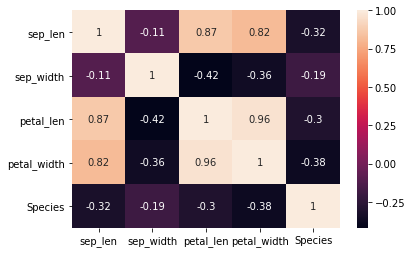

In [7]:
corr = iris.corr()
corr
sns.heatmap(corr, annot=True)
print("**************No features with correlation between -0.1 to 0.1***********")

In [8]:
#

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [9]:
# Variance of a variable is the square of stardard deviation 

iris.std()**2

sep_len        0.685694
sep_width      0.188004
petal_len      3.113179
petal_width    0.582414
Species        0.671141
dtype: float64

In [10]:
# Variance of features not below 0.1  -  Hence no drops

## Question 6

*Plot the scatter matrix for all the variables.*

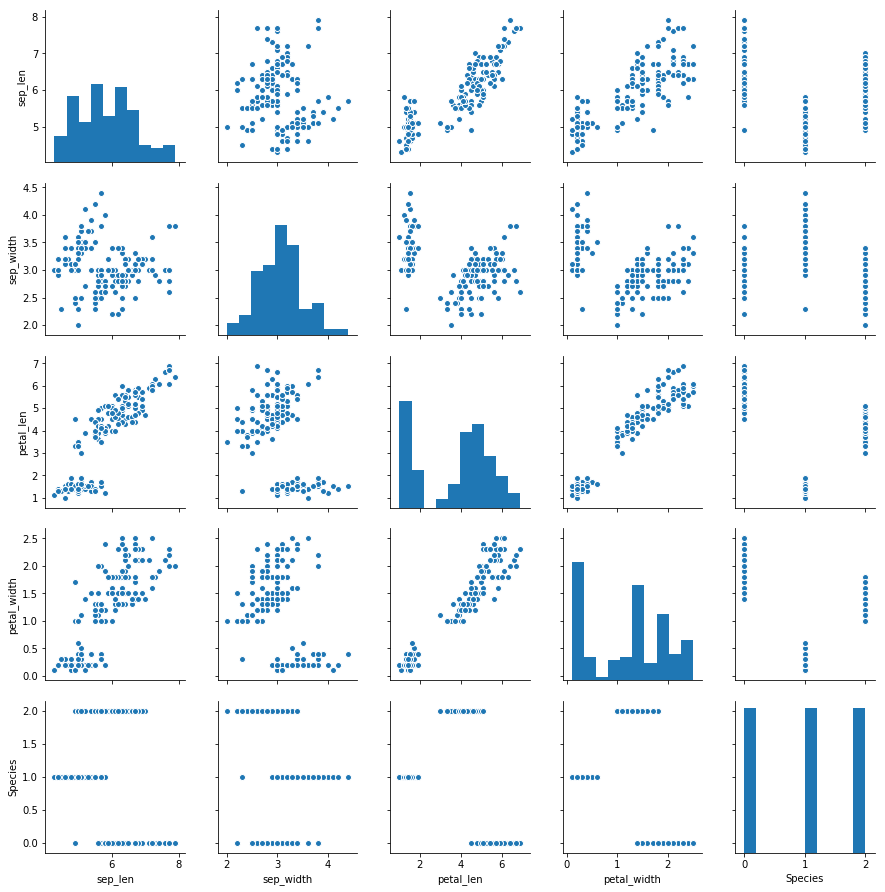

In [11]:
# Pairplot using sns
sns.pairplot(iris)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [12]:
X = iris.drop("Species", axis=1)
y = iris["Species"]



X = X.apply(zscore)


In [13]:
test_size = 0.20 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [14]:
y_test.value_counts()
y_train.value_counts()

2    12
0    11
1     7
Name: Species, dtype: int64

1    43
0    39
2    38
Name: Species, dtype: int64

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [15]:
NNH = KNeighborsClassifier(n_neighbors= 3)

In [16]:
NNH.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=3, p=2,
           weights='uniform')

In [17]:
for i in range(3,10,2):
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    predicted_labels = NNH.predict(X_test)
    predicted_labels1 = NNH.predict(X_train)
    print(" For KNN with ", i," neighbors the Accuracy of Model on Train ", NNH.score(X_train, y_train))
    print(" For KNN with ", i," neighbors the Accuracy of Model on Test ", NNH.score(X_test, y_test))


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=3, p=2,
           weights='uniform')

 For KNN with  3  neighbors the Accuracy of Model on Train  0.975
 For KNN with  3  neighbors the Accuracy of Model on Test  0.8666666666666667


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

 For KNN with  5  neighbors the Accuracy of Model on Train  0.975
 For KNN with  5  neighbors the Accuracy of Model on Test  0.9


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=7, p=2,
           weights='uniform')

 For KNN with  7  neighbors the Accuracy of Model on Train  0.9833333333333333
 For KNN with  7  neighbors the Accuracy of Model on Test  0.9333333333333333


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=9, p=2,
           weights='uniform')

 For KNN with  9  neighbors the Accuracy of Model on Train  0.975
 For KNN with  9  neighbors the Accuracy of Model on Test  0.9


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [18]:
cross_val=pd.DataFrame()

In [19]:
for i in range(1,30,2):
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    
    results1= pd.DataFrame(data=[i,NNH.score(X_train, y_train),1-NNH.score(X_train, y_train),
                                 NNH.score(X_test, y_test),1-NNH.score(X_test, y_test)],
                                 index=['neighbors','train_score','train_mse','test_score','test_mse']).T
    cross_val = cross_val.append(results1)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=1, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=3, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=7, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=9, p=2,
           weights='uniform')

...

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=21, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=23, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=25, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=27, p=2,
           weights='uniform')

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=29, p=2,
           weights='uniform')

In [20]:
cross_val=cross_val.sort_values(by="test_mse",ascending=True)
cross_val.head(1)

,neighbors,train_score,train_mse,test_score,test_mse
0,7.0,0.983333,0.016667,0.933333,0.066667


In [ ]:
# Lowest MSE for neighbors 7 

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

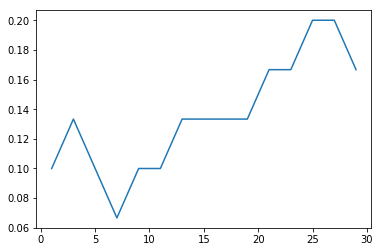

In [21]:
cross_val=cross_val.sort_values(by="neighbors",ascending=True)
plt.plot(cross_val['neighbors'],cross_val['test_mse']);

# Naive Bayes with Iris Data

In [22]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [23]:
# assigning column names to the data

colnames = ['sep_len', 'sep_width', 'petal_len', 'petal_width', 'Species']

iris = pd.read_csv("iris.data", names= colnames)
iris['Species'] = iris['Species'].replace({'Iris-virginica':0,'Iris-setosa':1,'Iris-versicolor':2})
iris['Species'].value_counts()
iris.head()
X = iris.drop("Species", axis=1)
y = iris["Species"]

2    50
1    50
0    50
Name: Species, dtype: int64

,sep_len,sep_width,petal_len,petal_width,Species
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [24]:
#Check the dataset
print(y)
print(X)



0      1
1      1
2      1
3      1
4      1
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
25     1
26     1
27     1
28     1
29     1
      ..
120    0
121    0
122    0
123    0
124    0
125    0
126    0
127    0
128    0
129    0
130    0
131    0
132    0
133    0
134    0
135    0
136    0
137    0
138    0
139    0
140    0
141    0
142    0
143    0
144    0
145    0
146    0
147    0
148    0
149    0
Name: Species, Length: 150, dtype: int64
     sep_len  sep_width  petal_len  petal_width
0        5.1        3.5        1.4          0.2
1        4.9        3.0        1.4          0.2
2        4.7        3.2        1.3          0.2
3        4.6        3.1        1.5          0.2
4        5.0        3.6        1.4          0.2
5        5.4        3.9        1.7          0.4
6        4.6        3.4        1.4          0.3
7        5.0        3.4   

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

2    50
1    50
0    50
Name: Species, dtype: int64

(array([50.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0., 50.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <a list of 10 Patch objects>)

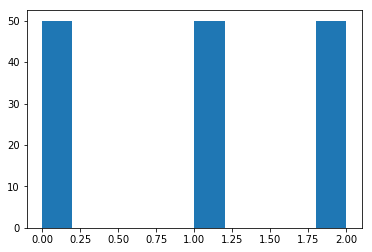

In [25]:
y.value_counts()

plt.hist(y)

In [26]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [27]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

,sep_len,sep_width,petal_len,petal_width,Species
sep_len,1.000000,-0.109369,0.871754,0.817954,-0.322522
sep_width,-0.109369,1.000000,-0.420516,-0.356544,-0.192719
petal_len,0.871754,-0.420516,1.000000,0.962757,-0.299942
petal_width,0.817954,-0.356544,0.962757,1.000000,-0.375715
Species,-0.322522,-0.192719,-0.299942,-0.375715,1.000000


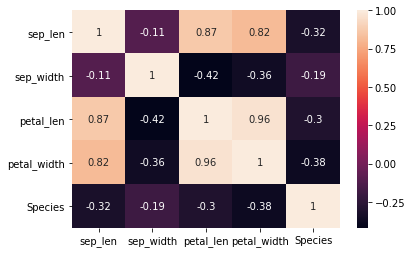

In [28]:
corr = iris.corr()
corr
sns.heatmap(corr, annot=True)

,sep_len,sep_width,petal_width,Species
sep_len,1.000000,-0.109369,0.817954,-0.322522
sep_width,-0.109369,1.000000,-0.356544,-0.192719
petal_width,0.817954,-0.356544,1.000000,-0.375715
Species,-0.322522,-0.192719,-0.375715,1.000000


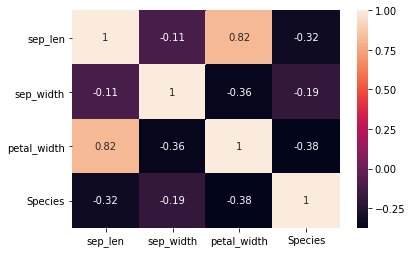

In [29]:
# Droping "Petal_len" from the model as it have correlation with petal width 
# ANd has lower correlation with species than petal width 

iris2= iris.drop("petal_len", axis=1)
corr = iris2.corr()
corr
sns.heatmap(corr, annot=True)

### Split data in Training and test set in 80:20.

In [30]:
test_size = 0.20 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [31]:
# Use StandardScaler or similar methods
scaler = StandardScaler().fit(X)
rescaledX = pd.DataFrame(scaler.transform(X))

In [32]:
X.describe()
rescaledX.describe()

,sep_len,sep_width,petal_len,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


,0,1,2,3
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-2.775558e-16,-5.140333e-16,1.154632e-16,9.251859e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


In [33]:
test_size = 0.20 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(rescaledX, y, test_size=test_size, random_state=seed)

### Question 14 
Train and Fit NaiveBayes Model

In [34]:
GNB = GaussianNB()

In [35]:
#Fit the model
GNB.fit(X_train, y_train)
print(GNB)

GaussianNB(priors=None)

GaussianNB(priors=None)


In [36]:
#Predict
preds = GNB.predict(X_test)
preds

array([0, 2, 1, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 0, 1, 0, 0, 0, 1, 1, 2, 0,
       2, 2, 0, 0, 2, 2, 0, 0], dtype=int64)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [37]:
# show Confusion Matrix
Confus_mat=metrics.confusion_matrix(preds, y_test)
y_test.value_counts()
Confus_mat

2    12
0    11
1     7
Name: Species, dtype: int64

array([[9, 0, 3],
       [0, 7, 0],
       [2, 0, 9]], dtype=int64)

In [48]:
# show accuracy
GNB.score(X_test, y_test)


0.8333333333333334

In [39]:
#Show precision and Recall metrics
results= pd.DataFrame(data=[accuracy_score(y_test, preds),recall_score(y_test, preds,average="macro"),
                            precision_score(y_test, preds, average="macro"),
                            f1_score(y_test, preds, average="macro")],
                      index=["accuracy", "recall", "precision", "f1_score"]).T

results

,accuracy,recall,precision,f1_score
0,0.833333,0.856061,0.856061,0.855072


# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [40]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [41]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [42]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [43]:
# use from sklearn.svm import SVC

In [44]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [45]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [46]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [47]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

NameError: name 'SVC' is not defined

In [ ]:
gs.fit(X_train_scaled, y_train) 

In [ ]:
gs.best_estimator_

In [ ]:
gs.best_score_ 